# Figures of **ICML 2026 Submission**

## Setup and Imports

In [3]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import expit

from data_models import *
from losses_regularizers import *
from erm_theory import ERMTrainer, TheoryFixedPointSolver

# For type hints
from numpy.typing import NDArray as Array

/workspaces/Empirical-risk-minimization-asymptotics/losses_regularizers.py:952: SyntaxWarning: invalid escape sequence '\e'
  """


### Configure Plotting Style

In [12]:
# Publication-quality styling
sns.set(style="whitegrid")
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 22,
    'legend.fontsize': 14,
    'lines.linewidth': 3,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'axes.grid': True,
    'grid.alpha': 0.2,
    'axes.facecolor': '#f9f9f9',
    'figure.facecolor': '#f9f9f9',
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial'],
})

# Custom color palette
colors = {
    'class_0': '#1f77b4',
    'class_1': '#ff7f0e',
    'theoretical': '#d62728',
    'gaussian': '#7f7f7f',
    'empirical': '#2ca02c',
    'background': '#f9f9f9',
    'grid': '#e0e0e0',
}

## Experiment 1: Gaussian universality breakdown in classification

To produce non Gaussian scores, we construct a Mode

In [35]:
c= 1
n_train = c*40
classes = [1, 0]
p = c*30  # Dimensionality of features
K = 2   # Number of classes (class 0 and class 1)

# Proportions for each class (uniform)
gamma = [0.4, 0.6]

# Means for each class
mus = [-1*np.ones(p)/np.sqrt(p), 1*np.ones(p)/np.sqrt(p)]  # Class 0 has mean at origin, class 1 at (1,1,...)

# Covariance matrices for each class (using diagonal matrices for simplicity)
covs = [0.2 * np.eye(p), 0.1 * np.eye(p)]  # Small variances for simplicity

# Sub-mode deltas for bimodal distribution (to create distinct sub-modes for each class)
sub_mode_deltas = [0.25*np.ones(p), 0.3*np.ones(p) ]  # Large separation between sub-modes for both classes

# Define the feature distribution (non-Gaussian)
feature_dist = "uniform_iid"  # This ensures non-Gaussian features

# Instantiate the MixtureClassificationModel
g1m1 = GaussianModel(p=p, mu= mus[0] +sub_mode_deltas[0], C = covs[0])
g1m2 = GaussianModel(p=p, mu= mus[0], C = covs[0])
g2m1 = GaussianModel(p=p, mu= mus[1] + sub_mode_deltas[1], C = covs[1])
g2m2 = GaussianModel(p=p, mu= mus[1], C=covs[1])

mix1 = MultimodalModel(components=[g1m1, g1m2], weights=np.array([0.6,0.4]))
mix2 = MultimodalModel(components=[g2m1, g2m2], weights=np.array([0.4,0.6]))
model = MultiClassModel(components=[mix1, mix2], gamma=gamma)

g1 = GaussianModel(p=p, mu= mix1.params()['mu'], C=mix1.params()['C'])
g2 = GaussianModel(p=p, mu= mix2.params()['mu'], C=mix2.params()['C'])
model_gaussian = MultiClassModel(components=[g1, g2], gamma=gamma)

In [ ]:

loss = LogisticLoss(max_iter=500, tol=1e-10)

# ============================================================
# EXPERIMENT PARAMETERS
# ============================================================
num_trials = 30
n_test = 5000
num_trials_th = 20000
lam_values = list(np.linspace(0.4, 0.01, 10))
rng = np.random.default_rng(1)

# ============================================================
# STORAGE
# ============================================================
emp_err, emp_std = [], []
th_err, gauss_err = [], []
class_err_emp, emp_err_gaussian, emp_std_gaussian = [], [], []
class_err_th, class_err_th_gaussian, th_err_gaussian, gauss_err_gaussian = [], [], [], []
scores_emp = {}
scores_th = {}

# ============================================================
# MAIN LOOP
# ============================================================
for i, lam in enumerate(lam_values):
    print(f'iter = {i},  lam = {lam:.4f}')
    reg = QuadraticRegularizer(a=np.zeros(p), H=lam * np.eye(p))
    trainer = ERMTrainer(model, loss, reg)
    trainer_gaussian = ERMTrainer(model_gaussian, loss, reg)
    emp = trainer.run_trials(
        n_train=n_train,
        num_trials=num_trials,
        rng=rng,
        solver_maxiter=2000,
        tol=1e-5,
        method="L-BFGS-B",
        verbose=False,
        n_test=n_test
    )
    emp_gaussian = trainer_gaussian.run_trials(
        n_train=n_train,
        num_trials=num_trials,
        rng=rng,
        solver_maxiter=2000,
        tol=1e-5,
        method="L-BFGS-B",
        verbose=False,
        n_test=n_test,    
    )
    solver = TheoryFixedPointSolver(
        model=model,
        loss=loss,
        regularizer=reg,
        n_train=n_train,
        mc_samples=10000,
        rng=rng,
    )
    solver_gaussian = TheoryFixedPointSolver(
        model=model_gaussian,
        loss=loss,
        regularizer=reg,
        n_train=n_train,
        mc_samples=10000,
        rng=rng,
    )
    th = solver.solve(max_iter=1000, tol=1e-5, damping=0.1)
    th_gaussian = solver_gaussian.solve(max_iter=1000, tol=1e-5, damping=0.1)
    emp_err.append(emp["gen_loss_mean"])
    emp_std.append(emp["gen_loss_std"])
    th_err.append(th["predicted_loss"])
    
    emp_err_gaussian.append(emp_gaussian["gen_loss_mean"])
    emp_std_gaussian.append(emp_gaussian["gen_loss_std"])
    th_err_gaussian.append(th_gaussian["predicted_loss"])
    params = model.class_params()
    predicted_loss_gauss = 0
    K = params['num_classes']
    mu = th['mu']
    for k in range(K):
        alpha_k = th['alpha'][k]
        Ck = params['covs'][k]
        muk = params['mus'][k]
        y = params['y_values'][k]
        predicted_loss_gauss += float(solver.model.gamma[k] * solver.loss.estimate_expected_loss_gaussian_score(y, muk, Ck, mu, float(alpha_k)))
    
    gauss_err_gaussian.append(predicted_loss_gauss)


# 4min

iter = 0,  lam = 0.4000
iter = 1,  lam = 0.3567
iter = 2,  lam = 0.3133
iter = 3,  lam = 0.2700
iter = 4,  lam = 0.2267
iter = 5,  lam = 0.1833
iter = 6,  lam = 0.1400
iter = 7,  lam = 0.0967
iter = 8,  lam = 0.0533
iter = 9,  lam = 0.0100


In [37]:
rng2 = np.random.default_rng(14)
num_trials_th = 100000
scores_emp = dict()
scores_th = dict()
z_samples = rng2.standard_normal(size=num_trials_th) 
for c_label in classes:  # MNIST classes are typically 0 and 1
    sc_emp=[]
    for i in range(num_trials):
        Xte, yte = model.sample_class(c_label, n_test, rng=rng2)
        sc_emp += [Xte[j]@emp['thetas'][i] for j in range(n_test)]
    scores_emp[c_label] = np.array(sc_emp)
    Xtetst, ytetst = model.sample_class(c_label,num_trials_th, rng=rng2)
    scores_th[c_label] = Xtetst@th["mu"] + th["alpha"][c_label]*z_samples

<>:131: SyntaxWarning: invalid escape sequence '\l'
<>:131: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_17000/2899345311.py:131: SyntaxWarning: invalid escape sequence '\l'
  axes[1].set_xlabel("Regularization Parameter ($\lambda$)", labelpad=10)


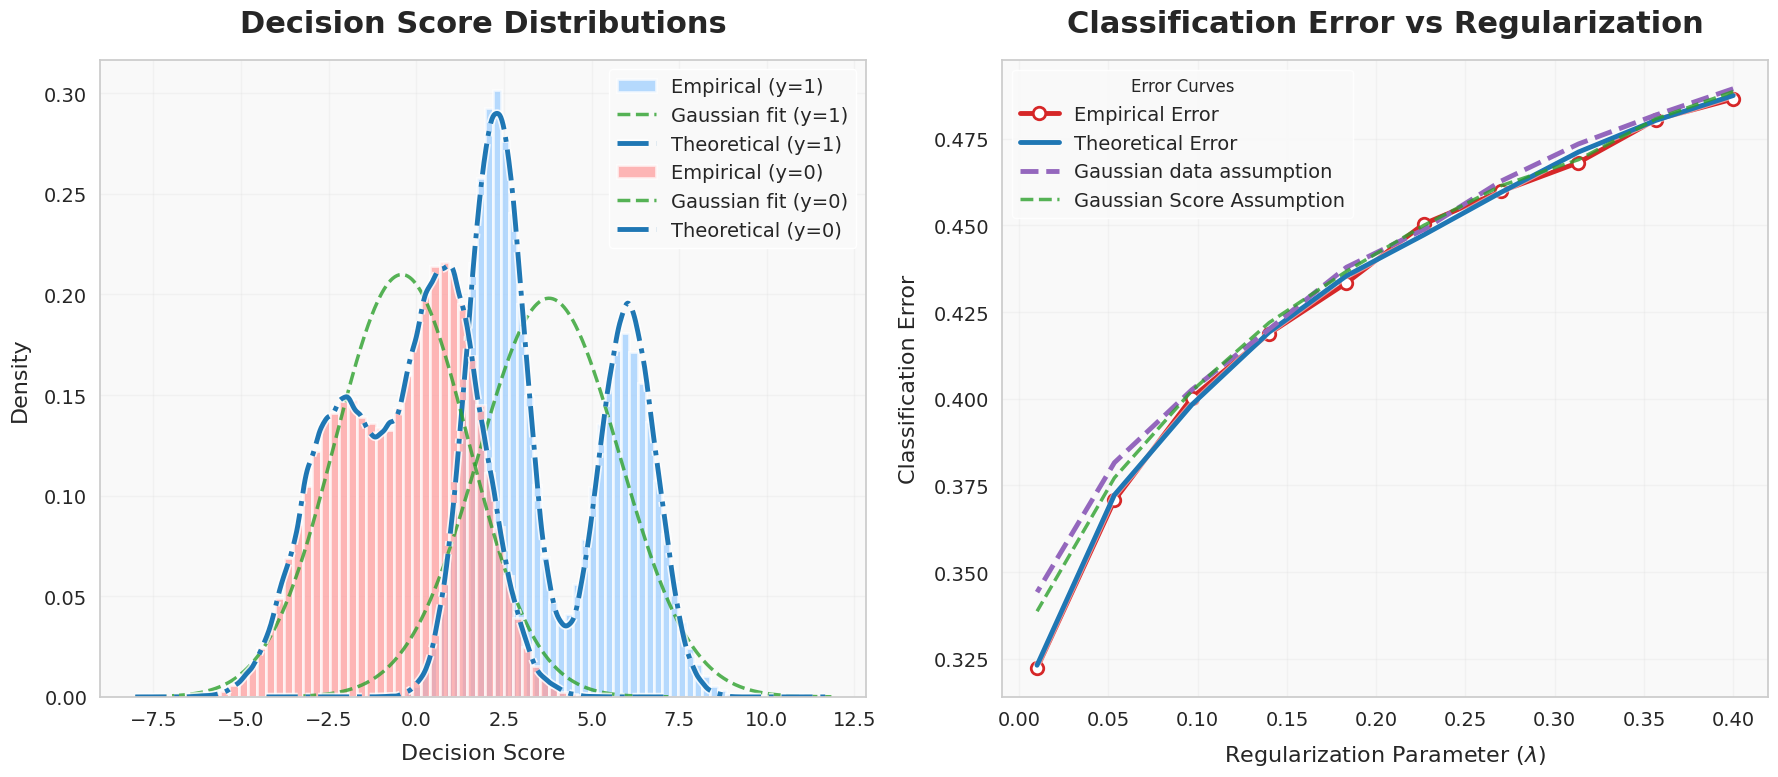

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.neighbors import KernelDensity
from matplotlib import patheffects
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# --- PLOT
# --- Define a refined, colorblind-friendly palette ---
colors = {
    'background': '#FFFFFF',
    'grid': '#E0E0E0',
    'empirical': '#D62728',    # Deep red
    'theoretical': '#1F77B4',  # Deep blue
    'gaussian_score': '#2CA02C',     # Green
    'gaussian': '#9467BD', # Purple
    'class_0': '#FF9999',      # Light red
    'class_1': '#99CCFF',      # Light blue
    'highlight': '#FF6347',    # Tomato Red
    'accent_line': '#3CB371',  # Medium Sea Green
}

emp_err = np.array(emp_err)
emp_std = np.array(emp_std)
th_err = np.array(th_err)
gauss_err = np.array(gauss_err)

emp_err_gaussian = np.array(emp_err_gaussian)
emp_std_gaussian = np.array(emp_std_gaussian)
th_err_gaussian = np.array(th_err_gaussian)
gauss_err_gaussian = np.array(gauss_err_gaussian)

# --- Create the figure ---
fig, axes = plt.subplots(1, 2, figsize=(18, 8), facecolor=colors['background'])
plt.subplots_adjust(wspace=0.25)

# --- LEFT PANEL: Histograms + PDFs ---
for c_label in classes:
    axes[0].hist(
        scores_emp[c_label],
        bins=50,
        density=True,
        alpha=0.7,
        color=colors['class_0'] if c_label == 0 else colors['class_1'],
        edgecolor='white',
        linewidth=2,
        label=f'Empirical (y={c_label})'
    )
    mu_c = np.mean(scores_th[c_label])
    std_c = np.std(scores_th[c_label])
    x = np.linspace(mu_c - 4 * std_c, mu_c + 4 * std_c, 500)
    axes[0].plot(
        x,
        norm.pdf(x, mu_c, std_c),
        '--',
        color=colors['gaussian_score'],
        linewidth=2.5,
        label=f'Gaussian fit (y={c_label})',
        alpha=0.8
    )
    kde = KernelDensity(kernel='gaussian', bandwidth=0.1).fit(scores_th[c_label].reshape(-1, 1))
    log_dens = kde.score_samples(x.reshape(-1, 1))
    axes[0].plot(
        x,
        np.exp(log_dens),
        color=colors['theoretical'],
        linewidth=3.5,
        linestyle='-.',
        label=f'Theoretical (y={c_label})',
        path_effects=[patheffects.withStroke(linewidth=6, foreground='white', alpha=0.8)]
    )

axes[0].set_title("Decision Score Distributions", pad=20, fontweight='bold')
axes[0].set_xlabel("Decision Score", labelpad=10)
axes[0].set_ylabel("Density", labelpad=10)
axes[0].legend(loc='upper right', frameon=True, framealpha=1, edgecolor='white')
axes[0].grid(True, linestyle='-', color=colors['grid'], alpha=0.3)

# --- RIGHT PANEL: Classification Error ---
axes[1].plot(
    lam_values,
    emp_err,
    color=colors['empirical'],
    linewidth=3.5,
    label='Empirical Error',
    marker='o',
    markersize=9,
    markerfacecolor='white',
    markeredgewidth=2,
    markeredgecolor=colors['empirical']
)
axes[1].plot(
    lam_values,
    th_err,
    color=colors['theoretical'],
    linewidth=3.5,
    label='Theoretical Error',
    path_effects=[patheffects.withStroke(linewidth=5, foreground='white', alpha=0.5)]
)
axes[1].plot(
    lam_values,
    emp_err_gaussian,
    '--',
    color=colors['gaussian'],
    linewidth=3.5,
    label='Gaussian data assumption',
    markerfacecolor='white',
    markeredgewidth=2,
    markeredgecolor=colors['gaussian']
)
axes[1].plot(
    lam_values,
    gauss_err_gaussian,
    '--',
    color=colors['gaussian_score'],
    linewidth=2.5,
    label='Gaussian Score Assumption',
    alpha=0.8
)

# --- Styling ---
axes[1].set_title("Classification Error vs Regularization", pad=20, fontweight='bold')
axes[1].set_xlabel("Regularization Parameter ($\lambda$)", labelpad=10)
axes[1].set_ylabel("Classification Error", labelpad=10)
axes[1].legend(loc='upper left', frameon=True, framealpha=0.9, edgecolor='white', title='Error Curves')
axes[1].grid(True, linestyle='-', color=colors['grid'], alpha=0.3)

# --- Save in high quality ---
plt.tight_layout()
# fig.savefig("ICML_teaser_figure.pdf", bbox_inches='tight', dpi=1200, transparent=True)
# fig.savefig("ICML_teaser_figure.png", bbox_inches='tight', dpi=1200, transparent=True)
plt.show()

## Experiment 2: Linear Factor Mixed Model

We construct a modified Linear Factor Mixed Model in which the $(q+1)$-th coordinate follows a two-component Gaussian mixture. This modification is introduced to demonstrate that our characterization of Gaussian universality continues to hold. In particular, adding a nonzero component to the quadratic regularization parameter 'a' along the $(q+1)$-th axis induces a corresponding component in $\mu_\star$. As a result, $X^\top \mu_\star$ exhibits non-Gaussian behavior alongside $X^\top \theta$. When this component is removed, the non-Gaussian behavior disappears from both.

### 2.1 Model Configuration

In [39]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import expit

from data_models import *
from losses_regularizers import *
from erm_theory import ERMTrainer, TheoryFixedPointSolver

# For type hints
from numpy.typing import NDArray as Array

In [40]:
# Model parameters
n_train = 50      # Training sample size (overparameterized regime: n < p)
p = 50            # Feature dimension
q = 1             # Number of signal-bearing coordinates
P = 0.5           # Label probability P(y = +1)
s = np.ones(q)    # Signal strength vector
noise_std = 1.0   # Standard deviation of additive noise

# Random number generators
rng = np.random.default_rng()

# Create model
model = LinearFactorMixedModel(
    p=p,
    q=q,
    P=P,
    s=s,
    noise_std=noise_std,
    y_type="gaussian",
    signal_type="modded"
)

# Loss function
loss = SquaredLoss()

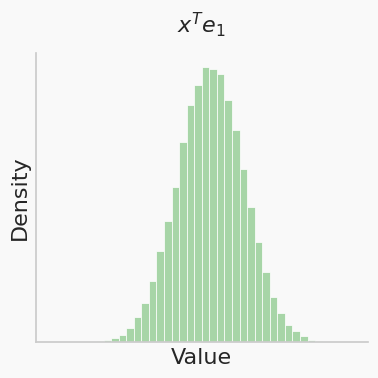

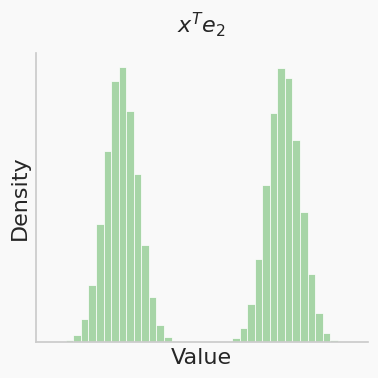

In [41]:
# Sample large dataset for visualization
NUM_SAMPLES_VIZ = 100_000
X_viz, y_viz = model.sample(NUM_SAMPLES_VIZ)

# Plot marginal distributions
titles = [r"$x^Te_1$", r"$x^Te_2$"]

for j in [0, 1]:
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.set_title(titles[j], fontsize=16, pad=15)
    
    # Histogram
    sns.histplot(
        X_viz[:, j],
        bins=40,
        stat="density",
        color="tab:green",
        alpha=0.4,
        edgecolor="white",
        label="Empirical",
        ax=ax,
    )
    
    # Minimal styling
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    
    sns.despine(ax=ax, trim=True)
    plt.tight_layout()
    plt.show()

### 2.2 Empirical Loss and prediction through Regularization Path
We vary the linear penalty vector $a$ along a circular path and study how the learned parameters $\hat{\theta}$ evolve.

The regularizer is: $\rho(\theta) = a^T \theta + \frac{\lambda}{2} \|\theta\|^2$

In [42]:
# Regularization parameters
lam = 1.0       # Quadratic penalty strength
nt = 20      # Number of steps along the path
n=1
# Create circular path in (e_1, e_2) plane
# Path: a(t) = (-cos(t), sin(t)) for t ∈ [0, π]
t_values = np.array([
    (-np.cos(t/nt * np.pi), np.sin(t/nt * np.pi)) 
    for t in range(0, nt + 1)
])

In [43]:
# Fixed-point solver parameters
mc_samples = 6000
fp_max_iter = 1000
fp_tol = 2e-5
fp_damping = 0.1

# Empirical parameters
n_test = 5000
num_trials = 30

# Initialize warm-start variables
mu0 = None
alpha0 = None
nu0 = None


⚠️ **Note**: This cell may take several minutes to complete.

In [ ]:


theory_preds = []
theory_converged = []
nu_theory = []
kappa_theory = []
alpha_theory = []
mu_theory =[]
empirical_means = []
empirical_stds = []

for t in t_values:
    print(f"\n===== t = {t} =====")

    # Define a vector a
    a = np.zeros(p)
    a[q-1] = t[0]
    a[q] = t[1]

    # Quadratic regularizer: (1/2) x^T H x + a^T x
    H = lam * np.eye(p)
    reg = QuadraticRegularizer(a=a, H=H)
            
    # ================= Empirical =================
    trainer = ERMTrainer(model=model, loss=loss, regularizer=reg)
    emp = trainer.run_trials(
        n_train=1,
        n_test=n_test,
        num_trials=num_trials,
        rng=rng,
        solver_maxiter=2000,
        tol=1e-6,
        method="L-BFGS-B",
        verbose=False,
    )

    empirical_means.append(emp["mean_theta"])
    empirical_stds.append(emp["cov_theta"])

    print(
        f"Empirical gen loss: mean={emp['gen_loss_mean']:.6f}  "
        f"std={emp['gen_loss_std']:.6f}"
    )

    # ================= Theory =================
    solver = TheoryFixedPointSolver(
        model=model,
        loss=loss,
        regularizer=reg,
        n_train=1,
        mc_samples=mc_samples,
        rng=np.random.default_rng(123),
    )

    th = solver.solve(
        max_iter=fp_max_iter,
        tol=fp_tol,
        damping=fp_damping,
        verbose=False,
        mu0=mu0,
        alpha0=alpha0,
        nu0=nu0,
    )

    theory_preds.append(th["predicted_loss"])
    theory_converged.append(bool(th["converged"]))

    # Warm start
    mu0, alpha0, nu0 = th["mu"], th["alpha"], th["nu"]
    nu_theory.append(th["nu"])
    kappa_theory.append(th["kappa"])
    alpha_theory.append(th["alpha"])
    mu_theory.append(th["mu"])

    print(
        f"Theory predicted loss: {th['predicted_loss']:.6f}  "
        f"(converged={th['converged']}, iters={th['num_iter']})"
    ) 

# 41s


===== t = [-1.  0.] =====


Empirical gen loss: mean=0.489009  std=0.020499
Theory predicted loss: 0.485492  (converged=False, iters=1000)

===== t = [-0.98768834  0.15643447] =====
Empirical gen loss: mean=0.491049  std=0.017903
Theory predicted loss: 0.489776  (converged=False, iters=1000)

===== t = [-0.95105652  0.30901699] =====
Empirical gen loss: mean=0.495799  std=0.016355
Theory predicted loss: 0.495516  (converged=False, iters=1000)

===== t = [-0.89100652  0.4539905 ] =====
Empirical gen loss: mean=0.506660  std=0.019141
Theory predicted loss: 0.506345  (converged=False, iters=1000)

===== t = [-0.80901699  0.58778525] =====
Empirical gen loss: mean=0.523131  std=0.017738
Theory predicted loss: 0.525531  (converged=False, iters=1000)

===== t = [-0.70710678  0.70710678] =====
Empirical gen loss: mean=0.553772  std=0.019678
Theory predicted loss: 0.557011  (converged=False, iters=1000)

===== t = [-0.58778525  0.80901699] =====
Empirical gen loss: mean=0.596335  std=0.014548
Theory predicted loss: 0.604


Compare empirical and theoretical mean squared errors along the regularization path.

In [45]:
def sample_empirical_theta(ns: int, idx: int) -> Array:
    """
    Sample from empirical distribution of θ̂.
    
    Parameters
    ----------
    ns : int
        Number of samples
    idx : int
        Index along regularization path
        
    Returns
    -------
    thetas : ndarray of shape (ns, p)
        Sampled parameter vectors
    """
    return np.random.multivariate_normal(
        empirical_means[idx], 
        empirical_stds[idx], 
        size=ns
    )

# Sample test data
NUM_TEST = 10_000
X_test, y_test = model.sample(NUM_TEST)
z_test = np.random.normal(size=NUM_TEST)

# Compute errors along path
empirical_errors = []
theoretical_errors = []

print("Computing prediction errors...")

for i in range(nt + 1):
    # Sample empirical parameters
    thetas = sample_empirical_theta(NUM_TEST, i)
    
    # Empirical predictions: x^T θ̂
    y_emp = np.einsum("ij,ij->i", X_test, thetas)
    
    # Theoretical predictions: x^T μ* + α z
    y_theory = X_test @ mu_theory[i] + alpha_theory[i][0]* z_test
    
    # Mean squared errors
    error_emp = np.mean((y_emp - y_test)**2)
    error_theory = np.mean((y_theory - y_test)**2)
    
    empirical_errors.append(error_emp)
    theoretical_errors.append(error_theory)

print(f"Error computation complete.")
print(f"  Empirical error range: [{min(empirical_errors):.4f}, {max(empirical_errors):.4f}]")
print(f"  Theoretical error range: [{min(theoretical_errors):.4f}, {max(theoretical_errors):.4f}]")

Computing prediction errors...


Error computation complete.
  Empirical error range: [0.9958, 4.8583]
  Theoretical error range: [0.9822, 4.8203]


Visualize Error Curves

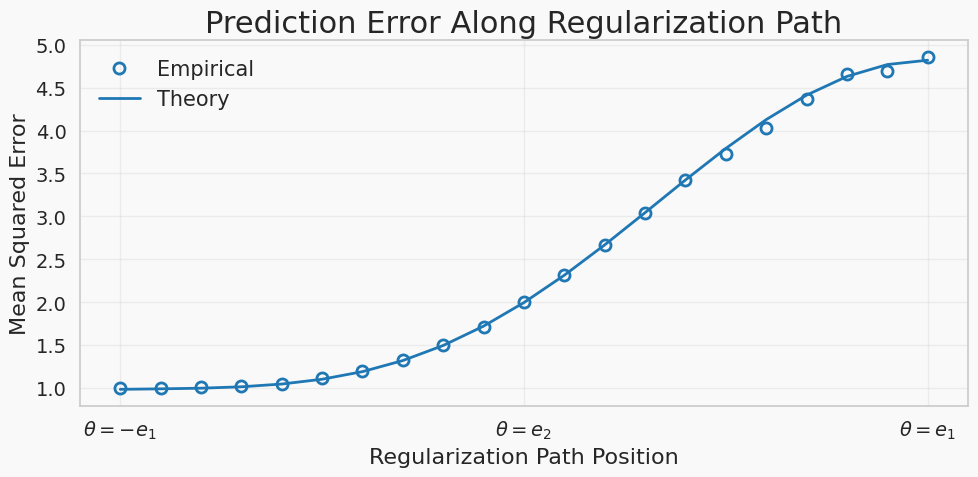


Average |empirical - theory| gap: 0.022353


In [46]:
fig, ax = plt.subplots(figsize=(10, 5))

# Plot empirical errors (hollow circles)
ax.plot(
    range(nt + 1),
    empirical_errors,
    color="tab:blue",
    marker="o",
    linestyle="None",
    markerfacecolor="none",
    markeredgewidth=2,
    markersize=8,
    label="Empirical",
    zorder=3,
)

# Plot theoretical errors (solid line)
ax.plot(
    range(nt + 1),
    theoretical_errors,
    color="tab:blue",
    linewidth=2,
    label="Theory",
    zorder=2,
)

# Customize x-axis labels
ax.set_xticks([0, nt//2, nt])
ax.set_xticklabels([r"$\theta=-e_1$", r"$\theta=e_2$", r"$\theta=e_1$"])

ax.set_xlabel("Regularization Path Position")
ax.set_ylabel("Mean Squared Error")
ax.set_title("Prediction Error Along Regularization Path")
ax.legend(fontsize=15, frameon=False)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Compute average gap
avg_gap = np.mean(np.abs(np.array(empirical_errors) - np.array(theoretical_errors)))
print(f"\nAverage |empirical - theory| gap: {avg_gap:.6f}")

### 2.3 Score Distribution Comparisons

Visualize how the distribution of decision scores $x^T \hat{\theta}$ compares to the theoretical prediction $x^T \mu_* + \alpha z$ at key points along the path.

More specifically when a = $-e_1$, $e_2$ and $e_1$

Select Key Points for Visualization

In [47]:
# Three key points: start, middle, end
KEY_INDICES = [0, nt//2, nt]
KEY_TITLES = [r"$a=-e_1$", r"$a=e_2$", r"$a=e_1$"]

print(f"Key points for visualization:")
for idx, title in zip(KEY_INDICES, KEY_TITLES):
    a_vec = t_values[idx]
    print(f"  {title}: a = ({a_vec[0]:.3f}, {a_vec[1]:.3f})")

Key points for visualization:
  $a=-e_1$: a = (-1.000, 0.000)
  $a=e_2$: a = (-0.000, 1.000)
  $a=e_1$: a = (1.000, 0.000)


Plot Score Distributions

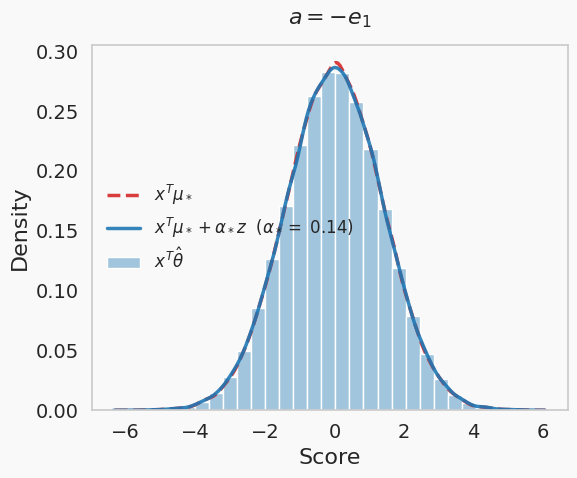

$a=-e_1$:
  Empirical: mean=-0.0006, std=1.3941
  Theory: mean=-0.0006, std=1.3897



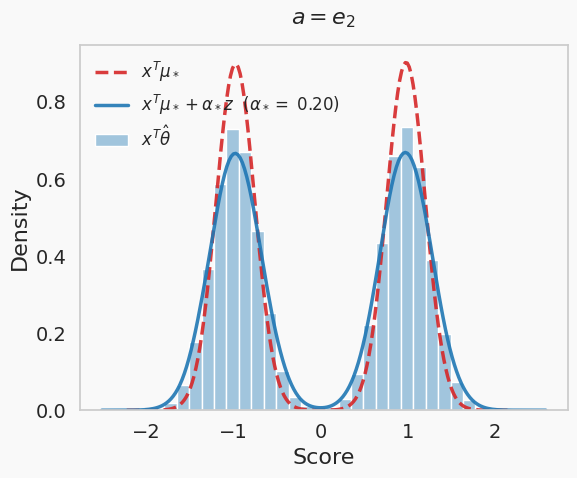

$a=e_2$:
  Empirical: mean=0.0016, std=1.0154
  Theory: mean=0.0026, std=1.0174



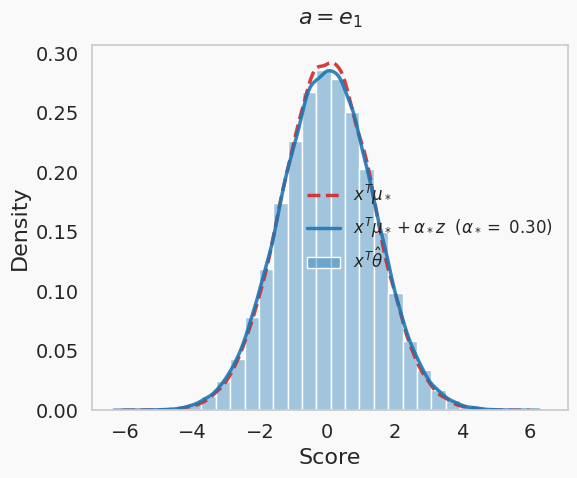

$a=e_1$:
  Empirical: mean=0.0005, std=1.3840
  Theory: mean=-0.0004, std=1.3734



In [48]:
# Sample size for distribution plots
NUM_DIST_SAMPLES = 100_000

for plot_idx, (path_idx, title) in enumerate(zip(KEY_INDICES, KEY_TITLES)):
    # Sample data
    X, y = model.sample(NUM_DIST_SAMPLES)
    thetas = sample_empirical_theta(NUM_DIST_SAMPLES, path_idx)
    z = np.random.normal(size=NUM_DIST_SAMPLES)
    
    # Compute scores
    scores_empirical = np.einsum("ij,ij->i", X, thetas)
    scores_theory_no_alpha = X @ mu_theory[path_idx] 
    scores_theory = X @ mu_theory[path_idx] + alpha_theory[path_idx][0]* z    # + alpha_theory[path_idx][0]* z
    
    # Create figure
    plt.figure(figsize=(6, 5))
    plt.title(title, fontsize=16, pad=15)
    
    # Empirical distribution
    sns.histplot(
        scores_empirical,
        bins=30,
        stat="density",
        color="tab:blue",
        alpha=0.4,
        edgecolor="white",
        label=r"$x^T \hat{\theta}$",
    )
    
    # Theoretical distribution (KDE)
    sns.kdeplot(
        scores_theory_no_alpha,
        color="tab:red",
        linewidth=2.5,
        linestyle='--',
        alpha=0.9,
        label=r"$x^T \mu_* $" ,
    )
    sns.kdeplot(
        scores_theory,
        color="tab:blue",
        linewidth=2.5,
        alpha=0.9,
        label=r"$x^T \mu_* + \alpha_*z$  ($\alpha_* =$ {alph:.2f})".format(alph=alpha_theory[path_idx][0]),
    )
    
    plt.xlabel("Score")
    plt.ylabel("Density")
    plt.legend(frameon=False, fontsize=12)
    plt.grid(False)
    
    plt.tight_layout()
    plt.show()
    
    print(f"{title}:")
    print(f"  Empirical: mean={scores_empirical.mean():.4f}, std={scores_empirical.std():.4f}")
    print(f"  Theory: mean={scores_theory.mean():.4f}, std={scores_theory.std():.4f}\n")

Comprehensive Multi-Panel Figure

/tmp/ipykernel_17000/1861943397.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


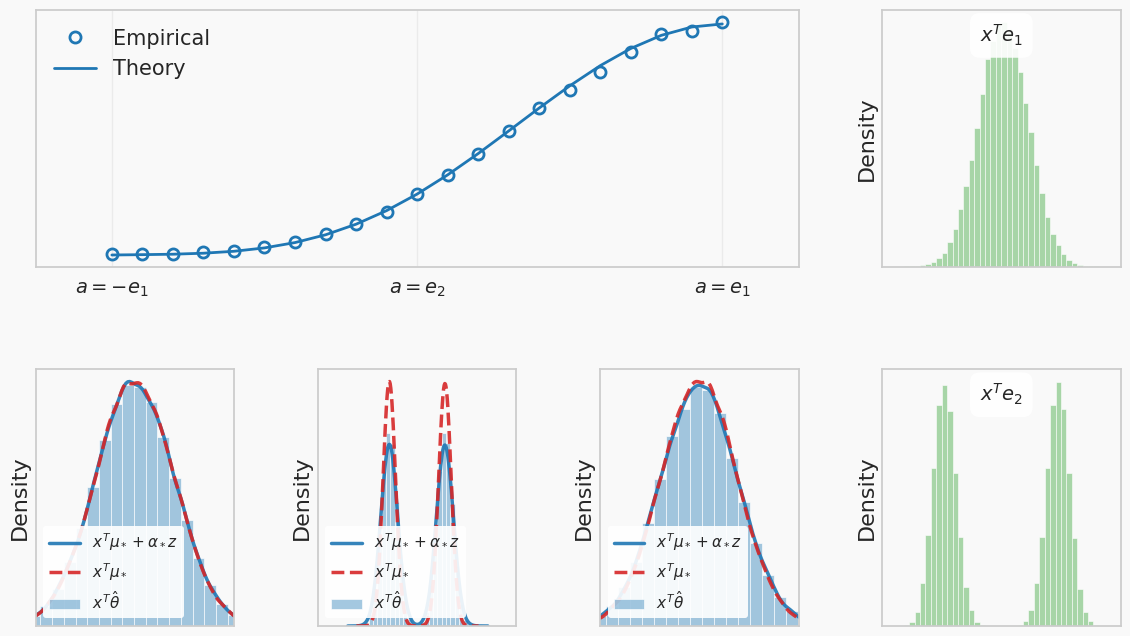

In [49]:
from matplotlib.gridspec import GridSpec

# Create figure with custom layout
fig = plt.figure(figsize=(14, 8))
gs = GridSpec(
    2, 4, 
    figure=fig, 
    hspace=0.4, 
    wspace=0.4,
    width_ratios=[1, 1, 1, 1.2], 
    height_ratios=[1, 1]
)

# Define subplots
ax_top = fig.add_subplot(gs[0, :3])           # Error curve
ax_bottom_left = fig.add_subplot(gs[1, 0])    # Score dist at a=-e1
ax_bottom_mid = fig.add_subplot(gs[1, 1])     # Score dist at a=e2
ax_bottom_right = fig.add_subplot(gs[1, 2])   # Score dist at a=e1
ax_right_top = fig.add_subplot(gs[0, 3])      # Feature marginal e1
ax_right_bottom = fig.add_subplot(gs[1, 3])   # Feature marginal e2

# -------------------------------------------------------------------------
# TOP PANEL: Error curve
# -------------------------------------------------------------------------
ax_top.plot(
    range(nt + 1),
    empirical_errors,
    color="tab:blue",
    marker="o",
    linestyle="None",
    markerfacecolor="none",
    markeredgewidth=2,
    markersize=8,
    label="Empirical",
    zorder=3,
)
ax_top.plot(
    range(nt + 1),
    theoretical_errors,
    color="tab:blue",
    linewidth=2,
    label="Theory",
    zorder=2,
)
ax_top.set_xticks([0, nt//2, nt])
ax_top.set_xticklabels([r"$a=-e_1$", r"$a=e_2$", r"$a=e_1$"])
ax_top.set_yticks([])
ax_top.legend(fontsize=15, frameon=False, loc='upper left')
ax_top.grid(True, alpha=0.3)
ax_top.set_xlim([-2.5, nt + 2.5])

# -------------------------------------------------------------------------
# BOTTOM PANELS: Score distributions
# -------------------------------------------------------------------------
X_panel, y_panel = model.sample(NUM_DIST_SAMPLES)

for ax, idx in zip([ax_bottom_left, ax_bottom_mid, ax_bottom_right], KEY_INDICES):
    thetas = sample_empirical_theta(NUM_DIST_SAMPLES, idx)
    scores_emp = np.einsum("ij,ij->i", X_panel, thetas)
    z = np.random.normal(size=NUM_DIST_SAMPLES)
    scores_th = X_panel @ mu_theory[idx] + alpha_theory[idx]*z
    scores_th_no_alpha = X_panel @ mu_theory[idx] 
    
    sns.histplot(
        scores_emp,
        bins=30,
        stat="density",
        color="tab:blue",
        alpha=0.4,
        edgecolor="white",
        label=r"$x^T \hat{\theta}$",
        ax=ax,
    )
    sns.kdeplot(
        scores_th,
        color="tab:blue",
        linewidth=2.5,
        alpha=0.9,
        label=r"$x^T \mu_* + \alpha_*z$",
        ax=ax,
    )
    sns.kdeplot(
        scores_th_no_alpha,
        color="tab:red",
        linewidth=2.5,
        linestyle='--',
        alpha=0.9,
        label=r"$x^T \mu_*$",
        ax=ax,
    )
    
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    ax.set_xlim([-3.5, 3.5])
    
    legend = ax.legend(frameon=True, fontsize=11, loc='lower left')
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.9)
    legend.get_frame().set_edgecolor('none')

# -------------------------------------------------------------------------
# RIGHT PANELS: Feature marginals
# -------------------------------------------------------------------------
for ax, coord, label in [(ax_right_top, 0, r"$x^Te_1$"), 
                          (ax_right_bottom, 1, r"$x^Te_2$")]:
    sns.histplot(
        X_panel[:, coord],
        bins=40,
        stat="density",
        color="tab:green",
        alpha=0.4,
        edgecolor="white",
        ax=ax
    )
    ax.text(
        0.5, 0.95, label,
        transform=ax.transAxes,
        fontsize=14,
        ha='center',
        va='top',
        bbox=dict(
            boxstyle='round,pad=0.5',
            facecolor='white',
            alpha=0.9,
            edgecolor='none'
        )
    )
    # ax.l
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)

plt.tight_layout()
plt.savefig("lfmm_comprehensive_figure.pdf", bbox_inches="tight", dpi=300)
plt.savefig("lfmm_comprehensive_figure.png", bbox_inches="tight", dpi=300)
plt.show()

---

## Experiment 3: Objective Landscape Analysis

Study the geometry of the objective function $J_\mu(\theta) = \mathbb{E}[\text{prox}_{\kappa L}(x^T \theta)] + \rho(\theta)$ near the optimum $\mu_*$.

### 3.1 Model Configuration
We now use a default Linear Factor Mixed Model since we no longer need the modification and calculate again the empirical and theoretical paramters.

Additionaly we set $a=e_2$ to investigate the contribution of $\mu_\star ^Te_2$ on the score $X^T\mu_\star$.

In [50]:
# Model parameters
n_train = 50      # Training sample size (overparameterized regime: n < p)
p = 50            # Feature dimension
q = 1             # Number of signal-bearing coordinates
P = 0.5           # Label probability P(y = +1)
s = np.ones(q)    # Signal strength vector
noise_std = 1.0   # Standard deviation of additive noise

# Random number generators
rng = np.random.default_rng()

# Create model
model = LinearFactorMixedModel(
    p=p,
    q=q,
    P=P,
    s=s,
    noise_std=noise_std,

)

# Loss function
loss = SquaredLoss()

In [51]:
# Define a vector a
a = np.zeros(p)
a[q] = 1

lam = 1.0

# Defining H 
H = lam * np.eye(p)

# Quadratic regularizer: (1/2) x^T H x + a^T x
reg = QuadraticRegularizer(a=a, H=H)
alpha0=None; mu0=None; nu0=None
        
# ================= Empirical =================
trainer = ERMTrainer(model=model, loss=loss, regularizer=reg)
emp = trainer.run_trials(
    n_train=1,
    n_test=n_test,
    num_trials=num_trials,
    rng=rng,
    solver_maxiter=2000,
    tol=1e-6,
    method="L-BFGS-B",
    verbose=False,
)
# ================= Theory =================
solver = TheoryFixedPointSolver(
    model=model,
    loss=loss,
    regularizer=reg,
    n_train=1,
    mc_samples=mc_samples,
    rng=np.random.default_rng(123),
)

th = solver.solve(
    max_iter=fp_max_iter,
    tol=fp_tol,
    damping=fp_damping,
    verbose=False,
    mu0=mu0,
    alpha0=alpha0,
    nu0=nu0,
)

mu_theory = th['mu']
kappa = th['kappa'][0]
alpha = th['alpha'][0]

### 3.2 Define Helper Functions

In [52]:
def logistic_moreau(
    z: Array, 
    kappa: float, 
    y: Array, 
    max_iter: int = 60, 
    tol: float = 1e-10
) -> Array:
    """
    Compute Moreau envelope for logistic loss.
    
    Returns: (1/2κ)|w-z|² + L(w,y) where w = prox_{κL}(z)
    """
    z = np.asarray(z, dtype=float)
    y = np.asarray(y, dtype=float)
    k = float(kappa)
    
    # Compute prox via Newton iterations
    w = z.copy()
    for _ in range(max_iter):
        t = y * w
        sig_t = expit(t)
        h = expit(-t)
        g = (w - z) - k * y * h
        gprime = 1.0 + k * sig_t * (1.0 - sig_t)
        
        step = g / gprime
        w_new = w - step
        
        if np.max(np.abs(w_new - w)) < tol:
            w = w_new
            break
        w = w_new
    
    # Compute Moreau envelope
    loss_val = LogisticLoss().value(w, y)
    return (w - z)**2 / (2*k) + loss_val 


def score_samples(n: int, mu: Array) -> tuple[Array, Array]:
    """Sample scores z = x^T μ + α z and labels."""
    z_noise = np.random.normal(size=n)
    X, y = model.sample(n)
    return X @ mu + alpha * z_noise, y


def evaluate_J_mu(
    t: float, 
    v: Array, 
    reg: QuadraticRegularizer, 
    n: int = 100
) -> float:
    """
    Evaluate J_μ(μ* + t*v).
    
    Parameters
    ----------
    t : float
        Step size along direction v
    v : Array
        Direction vector
    reg : QuadraticRegularizer
        Regularizer
    n : int
        Number of Monte Carlo samples
        
    Returns
    -------
    objective : float
        Value of objective function
    """
    mu_t = mu_theory + t * v    
    z, y = score_samples(n, mu_t)
    moreau_val = np.mean(logistic_moreau(z, kappa, y))
    
    return moreau_val + reg.value(mu_t)

print("Helper functions defined.")

Helper functions defined.


### 3.3 Compute Objective Along Different Directions

In [53]:
# Define regularizer (use first point on path)
reg_landscape = QuadraticRegularizer(a=a, H=H)

# Define test range
T_RANGE = np.linspace(-0.5, 0.5, 100)

# Define test directions
v_random = np.random.normal(size=p)         # Random direction
v_signal = np.random.normal(size=p)         # Signal subspace only
v_signal[q:] = 0

v_tangent = np.random.normal(size=p)        # Tangent to penalty
v_tangent[q+1:] = 0

print("Computing objective landscape...")
print("  This may take a few minutes...\n")

# Evaluate along each direction
obj_baseline = [evaluate_J_mu(t, np.zeros(p), reg_landscape, n=100000) for t in T_RANGE]
obj_random = [evaluate_J_mu(t, v_random, reg_landscape, n=100000) for t in T_RANGE]
obj_signal = [evaluate_J_mu(t, v_signal, reg_landscape, n=100000) for t in T_RANGE]
obj_tangent = [evaluate_J_mu(t, v_tangent, reg_landscape, n=100000) for t in T_RANGE]

print("Landscape computation complete.")


Computing objective landscape...
  This may take a few minutes...



Landscape computation complete.


### 3.4 Visualize Objective Landscape

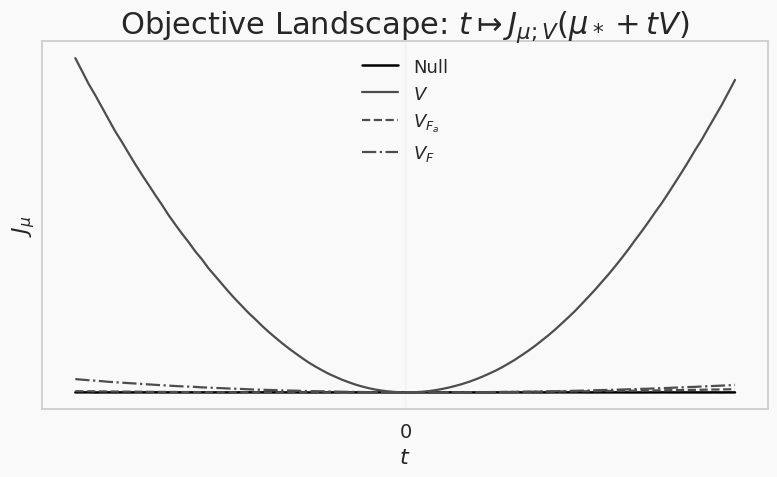

In [54]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(T_RANGE, obj_baseline, color="black", linewidth=1.8, label="Null")
ax.plot(T_RANGE, obj_random, color="0.3", linewidth=1.6, label=r"$V$")
ax.plot(T_RANGE, obj_tangent, color="0.3", linestyle="--", linewidth=1.6, label=r"$V_{F_a}$")
ax.plot(T_RANGE, obj_signal, color="0.3", linestyle="-.", linewidth=1.6, label=r"$V_F$")

ax.set_yticks([])
ax.set_xticks([0])
ax.set_xticklabels([r"$0$"])
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$J_\mu$")
ax.set_title(r"Objective Landscape: $t \mapsto J_{\mu;V}(\mu_* + tV)$")
ax.legend(fontsize=13, frameon=False)

plt.tight_layout()
plt.show()

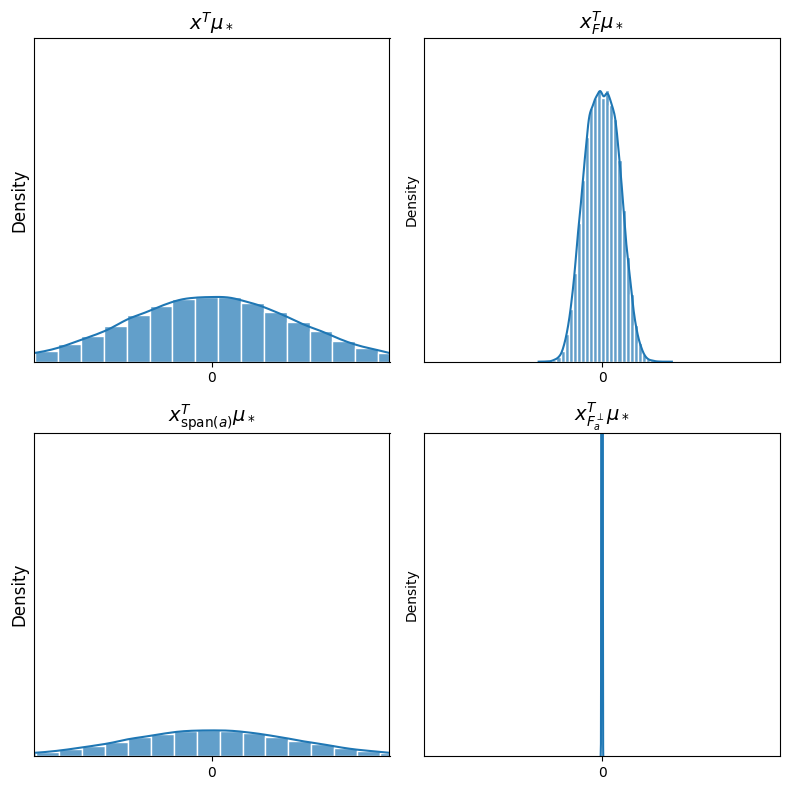


Projection Statistics:
$x^T\mu_*$: mean=-0.0002, std=0.9832
$x_F^T\mu_*$: mean=-0.0000, std=0.0276
$x_{\text{span}(a)}^T\mu_*$: mean=-0.0002, std=0.9827
$x_{F_a^\perp}^T\mu_*$: mean=0.0000, std=0.0017


In [25]:
# Sample test data
NUM_PROJ_SAMPLES = 50_000
X_proj, y_proj = model.sample(NUM_PROJ_SAMPLES)

# Use solution from first regularization point

# Define projections onto different subspaces
layer_full = X_proj @ mu_theory                    # Full: x^T μ*
layer_signal = X_proj[:, :q] @ mu_theory[:q]       # Signal: x_F^T μ*
layer_penalty = X_proj[:, q] * mu_theory[q]        # Penalty: x_{span(a)}^T μ*
layer_orthog = X_proj[:, q+1:] @ mu_theory[q+1:]   # Orthogonal: x_{F_a^⊥}^T μ*

# Create figure
titles = [
    r"$x^T\mu_*$",
    r"$x_F^T\mu_*$",
    r"$x_{\text{span}(a)}^T\mu_*$",
    r"$x_{F_a^\perp}^T\mu_*$"
]
samples_list = [layer_full, layer_signal, layer_penalty, layer_orthog]
xlimits = [(-2, 2),(-0.3, 0.3), (-2,2) , (-1, 1)]
ylimits = [(0, 2), (0, 15), (0, 5), (0, 5)]

fig, axes = plt.subplots(2, 2, figsize=(8, 8))

for ax, samples, title, xlimit , ylimit in zip(axes.flat, samples_list, titles, xlimits,ylimits):
    # Histogram
    sns.histplot(
        samples,
        bins=30,
        stat="density",
        kde=False,
        color="tab:blue",
        edgecolor="white",
        linewidth=1.0,
        alpha=0.7,
        ax=ax
    )
    
    # KDE overlay
    sns.kdeplot(
        samples,
        color="tab:blue",
        linewidth=1.5,
        linestyle="-",
        ax=ax
    )
    
    xmin, xmax = xlimit
    ymin, ymax = ylimit
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_title(title, fontsize=14)
    ax.set_xticks([0])
    ax.set_yticks([])

# Y-axis labels
axes[0, 0].set_ylabel("Density", fontsize=12)
axes[1, 0].set_ylabel("Density", fontsize=12)

plt.tight_layout()
plt.savefig("lfmm_subspace_projections.pdf", bbox_inches="tight", dpi=300)
plt.show()

print("\nProjection Statistics:")
for title, samples in zip(titles, samples_list):
    print(f"{title}: mean={samples.mean():.4f}, std={samples.std():.4f}")

## Experiment 4: Gaussian universality breakdown with real data



In [57]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import expit

from data_models import *
from losses_regularizers import *
from erm_theory import ERMTrainer, TheoryFixedPointSolver

# For type hints
from numpy.typing import NDArray as Array
c= 1
n_train = c*40
classes = [1, 0]
K = 2   # Number of classes (class 0 and class 1)

# Proportions for each class (uniform)
# gamma = [0.4, 0.6]
target_m = 13
W8 = create_downsampling_matrix(target_m=target_m, original_dim=28)
p = target_m**2  # Dimensionality of features

# Instantiate the MixtureClassificationModel
model = MNISTGroupedDataModel(
    data_path="./mnist.npz",
    split="train",
    stats_split="test",
    class_groups=[[1], [8]],
    W=W8,  # identity => raw pixels
    activation="identity",
    pixel_scaling="unit_interval",
    replace=False,
)

covs = model.class_params()['covs']
mus = model.class_params()['mus']
gamma = model.class_params()['gamma']
g1 = GaussianModel(p=p, mu= mus[0], C=covs[0])
g2 = GaussianModel(p=p, mu= mus[1], C=covs[1])
model_gaussian = MultiClassModel(components=[g1, g2], gamma=gamma)
# model_gaussian.validate_model_moments()
# model.validate_model_moments()

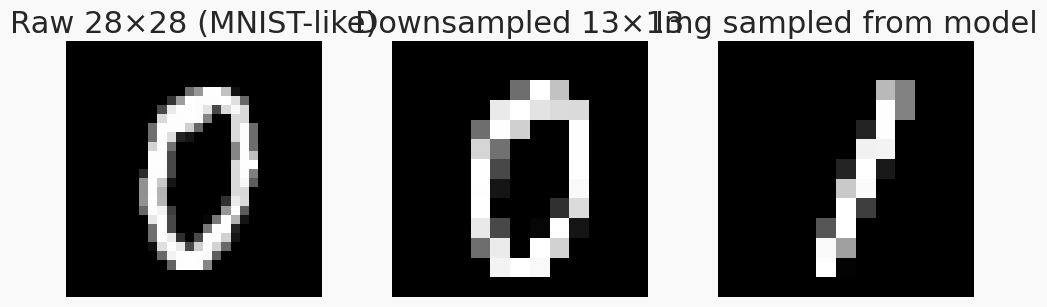

In [58]:
Mnist_raw = MNISTGroupedDataModel(
    data_path="./mnist.npz",
    split="train",
    stats_split="test",
    class_groups=[[0]],
    W=None,  # identity => raw pixels
    activation="identity",
    pixel_scaling="unit_interval",
    replace=False,
)
rng = np.random.default_rng(123)
X0, y0 = Mnist_raw.sample_class(0, 1, rng=rng)
Xtst, ytst = model.sample_class(0, 1, rng=rng)
img28 = X0[0].reshape(28, 28)
img8 = (X0[0] @ W8.T).reshape(target_m, target_m)
img_sampled = Xtst.reshape(target_m, target_m)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))
axes[0].imshow(img28, cmap="gray")
axes[0].set_title("Raw 28×28 (MNIST-like)")
axes[0].axis("off")

axes[1].imshow(img8, cmap="gray")
axes[1].set_title(f"Downsampled {target_m}×{target_m}")
axes[1].axis("off")

axes[2].imshow(img_sampled, cmap="gray")
axes[2].set_title("Img sampled from model")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:

loss = LogisticLoss(max_iter=500, tol=1e-10)

# ============================================================
# EXPERIMENT PARAMETERS
# ============================================================
num_trials = 30
n_test = 5000
num_trials_th = 20000
lam_values = list(np.linspace(0.4, 0.005, 20))
rng = np.random.default_rng(1)

# ============================================================
# STORAGE
# ============================================================
emp_err, emp_std = [], []
th_err, gauss_err = [], []
class_err_emp, emp_err_gaussian, emp_std_gaussian = [], [], []
class_err_th, class_err_th_gaussian, th_err_gaussian, gauss_err_gaussian = [], [], [], []
scores_emp = {}
scores_th = {}

# ============================================================
# MAIN LOOP
# ============================================================
for i, lam in enumerate(lam_values):
    print(f'\n=====ìter = {i}, λ = {lam:.4f} =====')
    reg = QuadraticRegularizer(a=np.zeros(p), H=lam * np.eye(p))
    trainer = ERMTrainer(model, loss, reg)
    trainer_gaussian = ERMTrainer(model_gaussian, loss, reg)
    emp = trainer.run_trials(
        n_train=n_train,
        num_trials=num_trials,
        rng=rng,
        solver_maxiter=2000,
        tol=1e-5,
        method="L-BFGS-B",
        verbose=False,
        n_test=n_test
    )
    emp_gaussian = trainer_gaussian.run_trials(
        n_train=n_train,
        num_trials=num_trials,
        rng=rng,
        solver_maxiter=2000,
        tol=1e-5,
        method="L-BFGS-B",
        verbose=False,
        n_test=n_test,    
    )
    solver = TheoryFixedPointSolver(
        model=model,
        loss=loss,
        regularizer=reg,
        n_train=n_train,
        mc_samples=4000,
        rng=rng,
    )
    solver_gaussian = TheoryFixedPointSolver(
        model=model_gaussian,
        loss=loss,
        regularizer=reg,
        n_train=n_train,
        mc_samples=4000,
        rng=rng,
    )
    th = solver.solve(max_iter=1000, tol=1e-5, damping=0.1)
    th_gaussian = solver_gaussian.solve(max_iter=1000, tol=1e-5, damping=0.1)
    emp_err.append(emp["gen_loss_mean"])
    emp_std.append(emp["gen_loss_std"])
    th_err.append(th["predicted_loss"])
    # gauss_err.append(th["predicted_loss_gauss"])
    
    emp_err_gaussian.append(emp_gaussian["gen_loss_mean"])
    emp_std_gaussian.append(emp_gaussian["gen_loss_std"])
    th_err_gaussian.append(th_gaussian["predicted_loss"])
    params = model.class_params()
    predicted_loss_gauss = 0
    K = params['num_classes']
    mu = th['mu']
    for k in range(K):
        alphak = th['alpha'][k]
        Ck = params['covs'][k]
        muk = params['mus'][k]
        y = params['y_values'][k]
        predicted_loss_gauss += float(solver.model.gamma[k] * solver.loss.estimate_expected_loss_gaussian_score(y, muk, Ck, mu, float(alpha_k)))
    gauss_err_gaussian.append(predicted_loss_gauss)


# 8m36


=====ìter = 0, λ = 0.4000 =====



=====ìter = 1, λ = 0.3792 =====

=====ìter = 2, λ = 0.3584 =====

=====ìter = 3, λ = 0.3376 =====

=====ìter = 4, λ = 0.3168 =====

=====ìter = 5, λ = 0.2961 =====

=====ìter = 6, λ = 0.2753 =====

=====ìter = 7, λ = 0.2545 =====

=====ìter = 8, λ = 0.2337 =====

=====ìter = 9, λ = 0.2129 =====

=====ìter = 10, λ = 0.1921 =====

=====ìter = 11, λ = 0.1713 =====

=====ìter = 12, λ = 0.1505 =====

=====ìter = 13, λ = 0.1297 =====

=====ìter = 14, λ = 0.1089 =====

=====ìter = 15, λ = 0.0882 =====

=====ìter = 16, λ = 0.0674 =====

=====ìter = 17, λ = 0.0466 =====

=====ìter = 18, λ = 0.0258 =====

=====ìter = 19, λ = 0.0050 =====


In [60]:
rng2 = np.random.default_rng(14)
num_trials_th = 2000
scores_emp = dict()
scores_th = dict()
z_samples = rng2.standard_normal(size=num_trials_th) 
for c_label in classes:  # MNIST classes are typically 0 and 1
    sc_emp=[]
    for i in range(num_trials):
        Xte, yte = model.sample_class(c_label, n_test, rng=rng2)
        sc_emp += [Xte[j]@emp['thetas'][i] for j in range(n_test)]
    scores_emp[c_label] = np.array(sc_emp)
    Xtetst, ytetst = model.sample_class(c_label,num_trials_th, rng=rng2)
    scores_th[c_label] = Xtetst@th["mu"] + th["alpha"][c_label]*z_samples

<>:148: SyntaxWarning: invalid escape sequence '\l'
<>:148: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_17000/2216317823.py:148: SyntaxWarning: invalid escape sequence '\l'
  axes[1].set_xlabel("Regularization Parameter ($\lambda$)", labelpad=10)


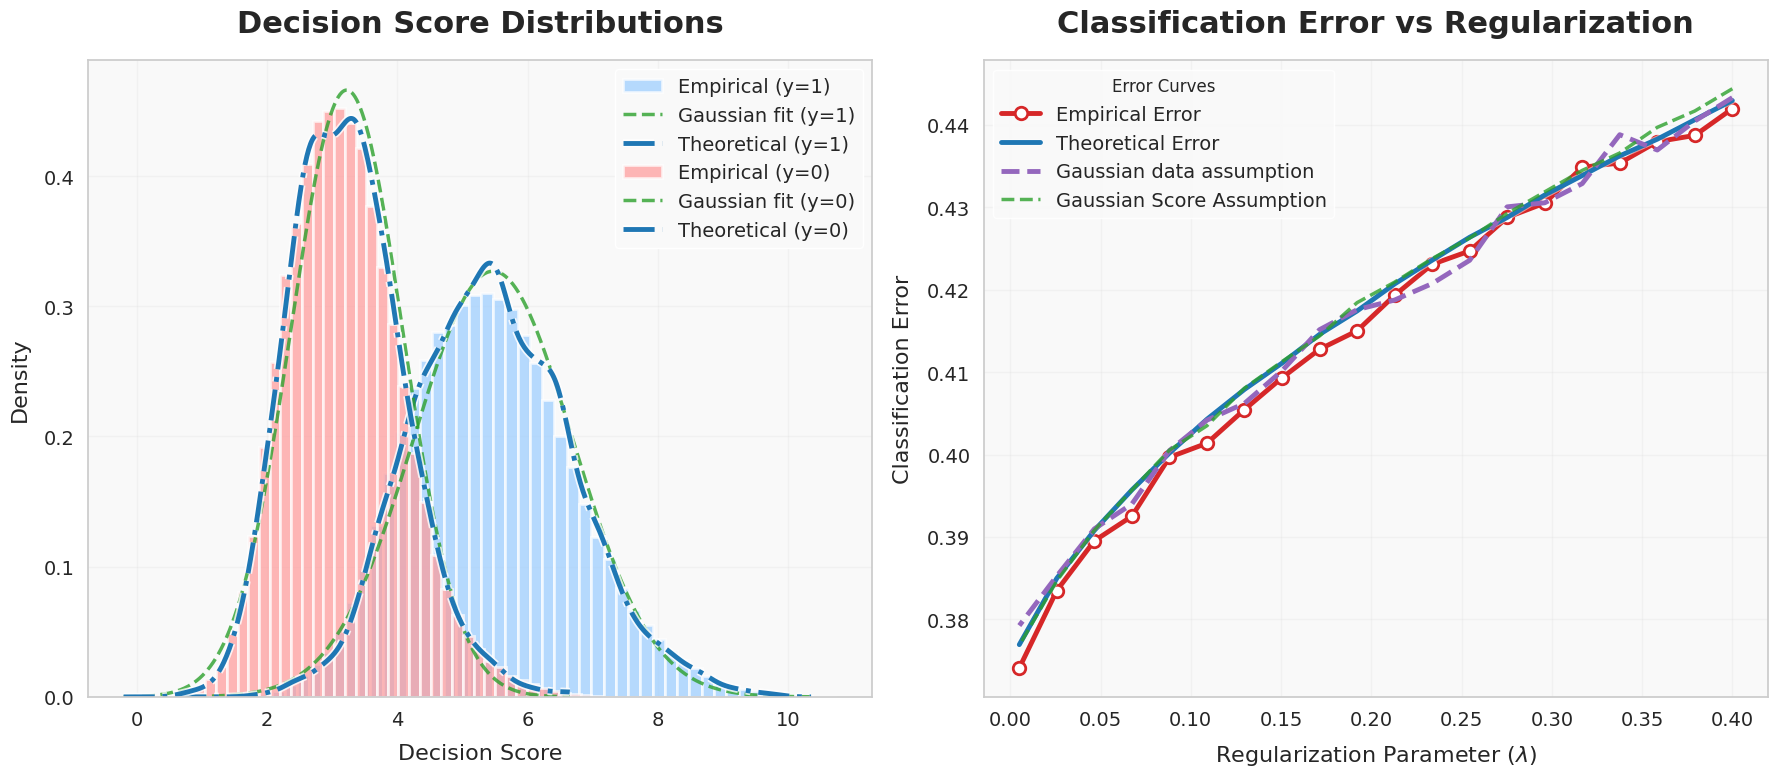

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.neighbors import KernelDensity
from matplotlib import patheffects
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# --- PLOT
# --- Define a refined, colorblind-friendly palette ---
# Publication-quality styling
sns.set(style="whitegrid")
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 22,
    'legend.fontsize': 14,
    'lines.linewidth': 3,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'axes.grid': True,
    'grid.alpha': 0.2,
    'axes.facecolor': '#f9f9f9',
    'figure.facecolor': '#f9f9f9',
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial'],
})
colors = {
    'background': '#FFFFFF',
    'grid': '#E0E0E0',
    'empirical': '#D62728',    # Deep red
    'theoretical': '#1F77B4',  # Deep blue
    'gaussian_score': '#2CA02C',     # Green
    'gaussian': '#9467BD', # Purple
    'class_0': '#FF9999',      # Light red
    'class_1': '#99CCFF',      # Light blue
    'highlight': '#FF6347',    # Tomato Red
    'accent_line': '#3CB371',  # Medium Sea Green
}

emp_err = np.array(emp_err)
emp_std = np.array(emp_std)
th_err = np.array(th_err)
gauss_err = np.array(gauss_err)

emp_err_gaussian = np.array(emp_err_gaussian)
emp_std_gaussian = np.array(emp_std_gaussian)
th_err_gaussian = np.array(th_err_gaussian)
gauss_err_gaussian = np.array(gauss_err_gaussian)

# --- Create the figure ---
fig, axes = plt.subplots(1, 2, figsize=(18, 8), facecolor=colors['background'])
plt.subplots_adjust(wspace=0.25)

# --- LEFT PANEL: Histograms + PDFs ---
for c_label in classes:
    axes[0].hist(
        scores_emp[c_label],
        bins=50,
        density=True,
        alpha=0.7,
        color=colors['class_0'] if c_label == 0 else colors['class_1'],
        edgecolor='white',
        linewidth=2,
        label=f'Empirical (y={c_label})'
    )
    mu_c = np.mean(scores_th[c_label])
    std_c = np.std(scores_th[c_label])
    x = np.linspace(mu_c - 4 * std_c, mu_c + 4 * std_c, 500)
    axes[0].plot(
        x,
        norm.pdf(x, mu_c, std_c),
        '--',
        color=colors['gaussian_score'],
        linewidth=2.5,
        label=f'Gaussian fit (y={c_label})',
        alpha=0.8
    )
    kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(scores_th[c_label].reshape(-1, 1))
    log_dens = kde.score_samples(x.reshape(-1, 1))
    axes[0].plot(
        x,
        np.exp(log_dens),
        color=colors['theoretical'],
        linewidth=3.5,
        linestyle='-.',
        label=f'Theoretical (y={c_label})',
        path_effects=[patheffects.withStroke(linewidth=6, foreground='white', alpha=0.8)]
    )

axes[0].set_title("Decision Score Distributions", pad=20, fontweight='bold')
axes[0].set_xlabel("Decision Score", labelpad=10)
axes[0].set_ylabel("Density", labelpad=10)
axes[0].legend(loc='upper right', frameon=True, framealpha=1, edgecolor='white')
axes[0].grid(True, linestyle='-', color=colors['grid'], alpha=0.3)

# --- RIGHT PANEL: Classification Error ---
axes[1].plot(
    lam_values,
    emp_err,
    color=colors['empirical'],
    linewidth=3.5,
    label='Empirical Error',
    marker='o',
    markersize=9,
    markerfacecolor='white',
    markeredgewidth=2,
    markeredgecolor=colors['empirical']
)
# axes[1].fill_between(
#     lam_values,
#     emp_err - emp_std,
#     emp_err + emp_std,
#     color=colors['empirical'],
#     alpha=0.15
# )
axes[1].plot(
    lam_values,
    th_err,
    color=colors['theoretical'],
    linewidth=3.5,
    label='Theoretical Error',
    path_effects=[patheffects.withStroke(linewidth=5, foreground='white', alpha=0.5)]
)
axes[1].plot(
    lam_values,
    emp_err_gaussian,
    '--',
    color=colors['gaussian'],
    linewidth=3.5,
    label='Gaussian data assumption',
    markerfacecolor='white',
    markeredgewidth=2,
    markeredgecolor=colors['gaussian']
)
axes[1].plot(
    lam_values,
    gauss_err_gaussian,
    '--',
    color=colors['gaussian_score'],
    linewidth=2.5,
    label='Gaussian Score Assumption',
    alpha=0.8
)

# --- Styling ---
axes[1].set_title("Classification Error vs Regularization", pad=20, fontweight='bold')
axes[1].set_xlabel("Regularization Parameter ($\lambda$)", labelpad=10)
axes[1].set_ylabel("Classification Error", labelpad=10)
axes[1].legend(loc='upper left', frameon=True, framealpha=0.9, edgecolor='white', title='Error Curves')
axes[1].grid(True, linestyle='-', color=colors['grid'], alpha=0.3)

# --- Save in high quality ---
plt.tight_layout()
# fig.savefig("ICML_teaser_figure.pdf", bbox_inches='tight', dpi=1200, transparent=True)
# fig.savefig("ICML_teaser_figure.png", bbox_inches='tight', dpi=1200, transparent=True)
plt.show()